In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print('Libraries loaded!')

Libraries loaded!


In [7]:
# Cell 2: Generate synthetic sensor data

np.random.seed(42)

# Define parameters
n_machines = 8
machines = ['M01', 'M02', 'M03', 'M04', 'M05', 'M06', 'M07', 'M08']
# Generate 6 months of hourly timestamps
dates = pd.date_range(start='2025-01-01', periods=24*180, freq='h')  # use pd.date_range, start 2025-01-01, 
                                                                  # periods = 24*180 (24hrs * 180 days), freq='h'

# Build the dataset — one row per machine per hour
rows = []
for machine in machines:
    for date in dates:
        # Normal sensor readings
        temperature = np.random.normal(70,5)  # np.random.normal, mean=70, std=5
        vibration = np.random.normal(1.8,0.4)    # np.random.normal, mean=0.5, std=0.1
        current = np.random.normal(1.5,0.2)     # np.random.normal, mean=15, std=2

        rows.append({
            'machine_id': machine,
            'timestamp': date,
            'temperature': round(temperature, 2),
            'vibration': round(vibration, 2),
            'current': round(current, 2)
        })

df = pd.DataFrame(rows)
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset shape: (34560, 5)
Date range: 2025-01-01 00:00:00 to 2025-06-29 23:00:00

First 5 rows:
  machine_id           timestamp  temperature  vibration  current
0        M01 2025-01-01 00:00:00        72.48       1.74     1.63
1        M01 2025-01-01 01:00:00        77.62       1.71     1.45
2        M01 2025-01-01 02:00:00        77.90       2.11     1.41
3        M01 2025-01-01 03:00:00        72.71       1.61     1.41
4        M01 2025-01-01 04:00:00        71.21       1.03     1.16


In [11]:
# Cell 3: Inject realistic anomalies

np.random.seed(99)

# Create anomaly flag column — default all False
df['is_anomaly'] = False

# Inject anomalies into ~3% of rows
aanomaly_mask = np.random.random(len(df)) < 0.03  # np.random.random(len(df)) < 0.03

# Spike temperature on anomalous rows
df.loc[anomaly_mask, 'temperature'] += np.random.normal(20, 5, anomaly_mask.sum())  # normal, mean=20, std=5, size=anomaly_mask.sum()

# Spike vibration on anomalous rows  
df.loc[anomaly_mask, 'vibration'] += np.random.normal(3, 1, anomaly_mask.sum())  # normal, mean=3, std=0.8, size=anomaly_mask.sum()

# Spike current on anomalous rows
df.loc[anomaly_mask, 'current'] += np.random.normal(0.7, 0.2, anomaly_mask.sum())  # normal, mean=0.7, std=0.2, size=anomaly_mask.sum()

# Mark anomalous rows
df.loc[anomaly_mask, 'is_anomaly'] = True

# Verify
print(f"Total rows: {len(df)}")
print(f"Anomalies injected: {df['is_anomaly'].sum()}")
print(f"Anomaly %: {df['is_anomaly'].mean()*100:.2f}%")
print(f"\nNormal readings avg temperature: {df[df['is_anomaly']==False]['temperature'].mean():.2f}")
print(f"Anomalous readings avg temperature: {df[df['is_anomaly']==True]['temperature'].mean():.2f}")

Total rows: 34560
Anomalies injected: 1053
Anomaly %: 3.05%

Normal readings avg temperature: 69.97
Anomalous readings avg temperature: 110.00


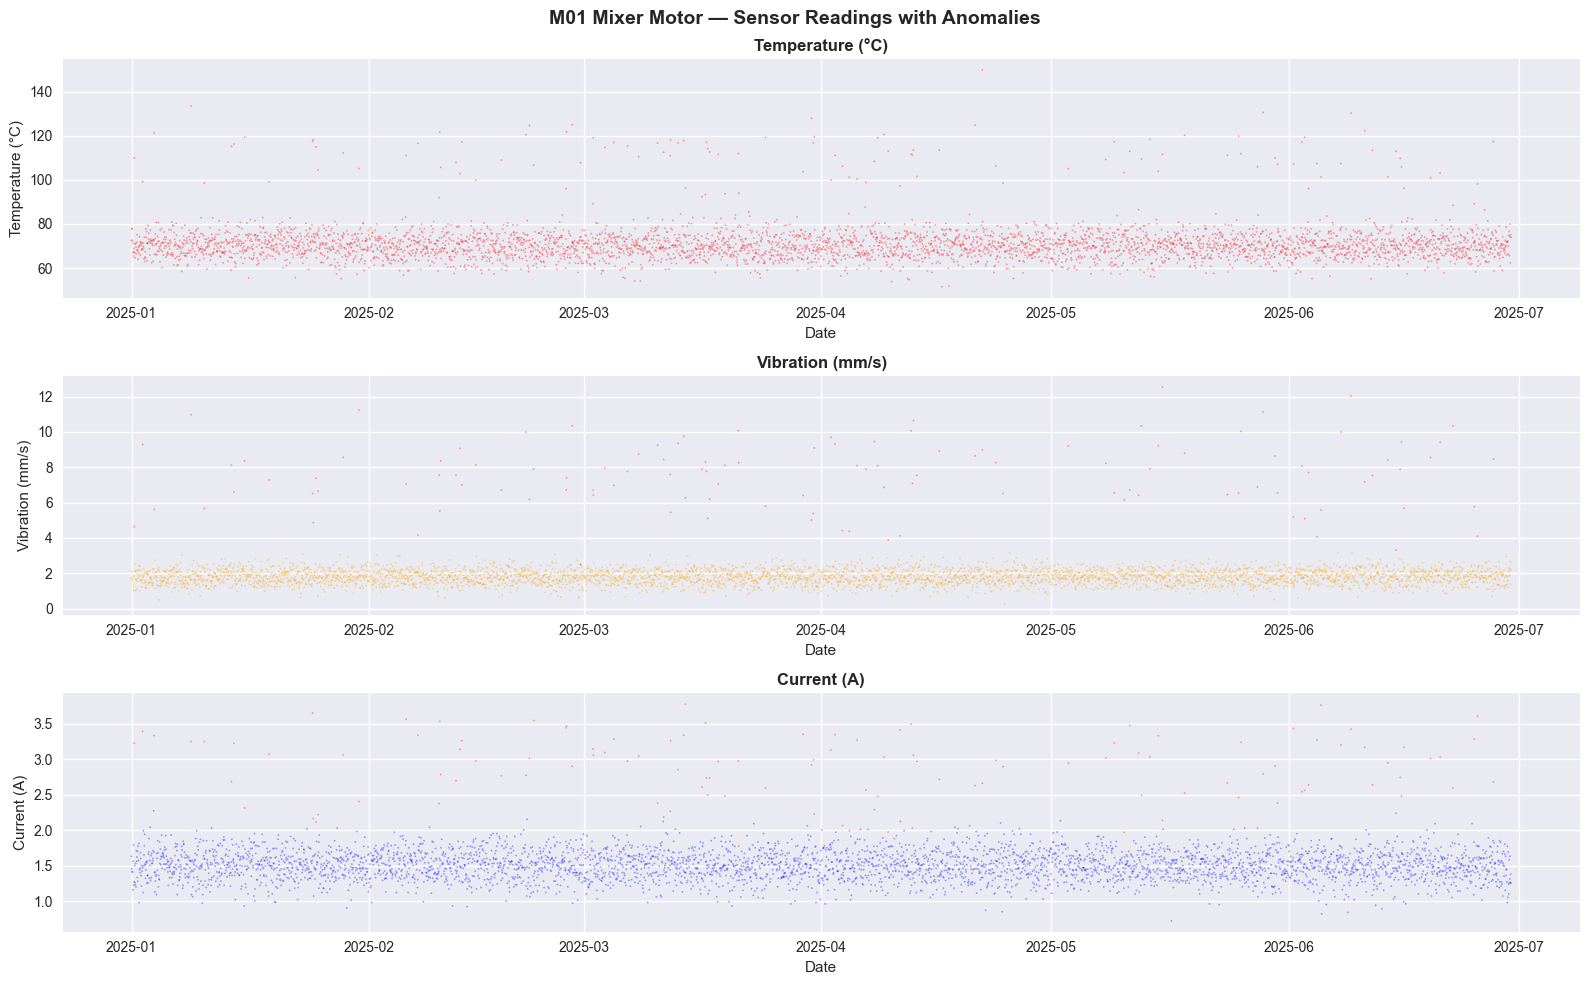

Cell 4 done!


In [12]:
# Cell 4: Visualize sensor readings and anomalies for M01

m01 = df[df['machine_id'] == 'M01'].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle('M01 Mixer Motor — Sensor Readings with Anomalies', 
             fontsize=14, fontweight='bold')

sensors = ['temperature', 'vibration', 'current']
titles = ['Temperature (°C)', 'Vibration (mm/s)', 'Current (A)']
colors = ['red', 'orange', 'blue']

for i, (sensor, title, color) in enumerate(zip(sensors, titles, colors)):
    axes[i].scatter(
        m01['timestamp'],
        m01[sensor],
        c=m01['is_anomaly'].map({True: 'red', False: color}),
        alpha=0.3,
        s=1
    )
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel(title)

plt.tight_layout()
plt.savefig('../data/sensor_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 4 done!")

In [13]:
# Cell 5: Train Isolation Forest Model

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Select features for the model
features = ['temperature', 'vibration', 'current']
X = df[features]
# X is our feature matrix — the inputs to the model
# We don't include machine_id, timestamp, or is_anomaly

# Step 2: Scale features so all three contribute equally
scaler = StandardScaler()  # StandardScaler()
X_scaled = scaler.fit_transform(X)  # scaler.fit_transform(X)

# Step 3: Train Isolation Forest
model = IsolationForest(
    n_estimators=100,   # 100 trees
    contamination=0.03, # 0.03 — we injected 3% anomalies
    random_state=42  # 42
)

# Step 4: Fit and predict
predictions = model.fit_predict(X_scaled) # model.fit_predict(X_scaled)
# Returns 1 for normal, -1 for anomaly

# Step 5: Add predictions to dataframe
df['predicted_anomaly'] = predictions == -1  # predictions == -1

# Step 6: Evaluate the model
print("=== Model Evaluation ===")
print(f"Total anomalies predicted: {df['predicted_anomaly'].sum()}")
print(f"Total actual anomalies: {df['is_anomaly'].sum()}")
print(f"\nClassification Report:")
print(classification_report(df['is_anomaly'], df['predicted_anomaly']))

print("\nConfusion Matrix:")
cm = confusion_matrix(df['is_anomaly'], df['predicted_anomaly'])
print(cm)
print(f"\nTN: {cm[0,0]}  FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}  TP: {cm[1,1]}")

=== Model Evaluation ===
Total anomalies predicted: 1037
Total actual anomalies: 1053

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     33507
        True       1.00      0.98      0.99      1053

    accuracy                           1.00     34560
   macro avg       1.00      0.99      1.00     34560
weighted avg       1.00      1.00      1.00     34560


Confusion Matrix:
[[33507     0]
 [   16  1037]]

TN: 33507  FP: 0
FN: 16  TP: 1037


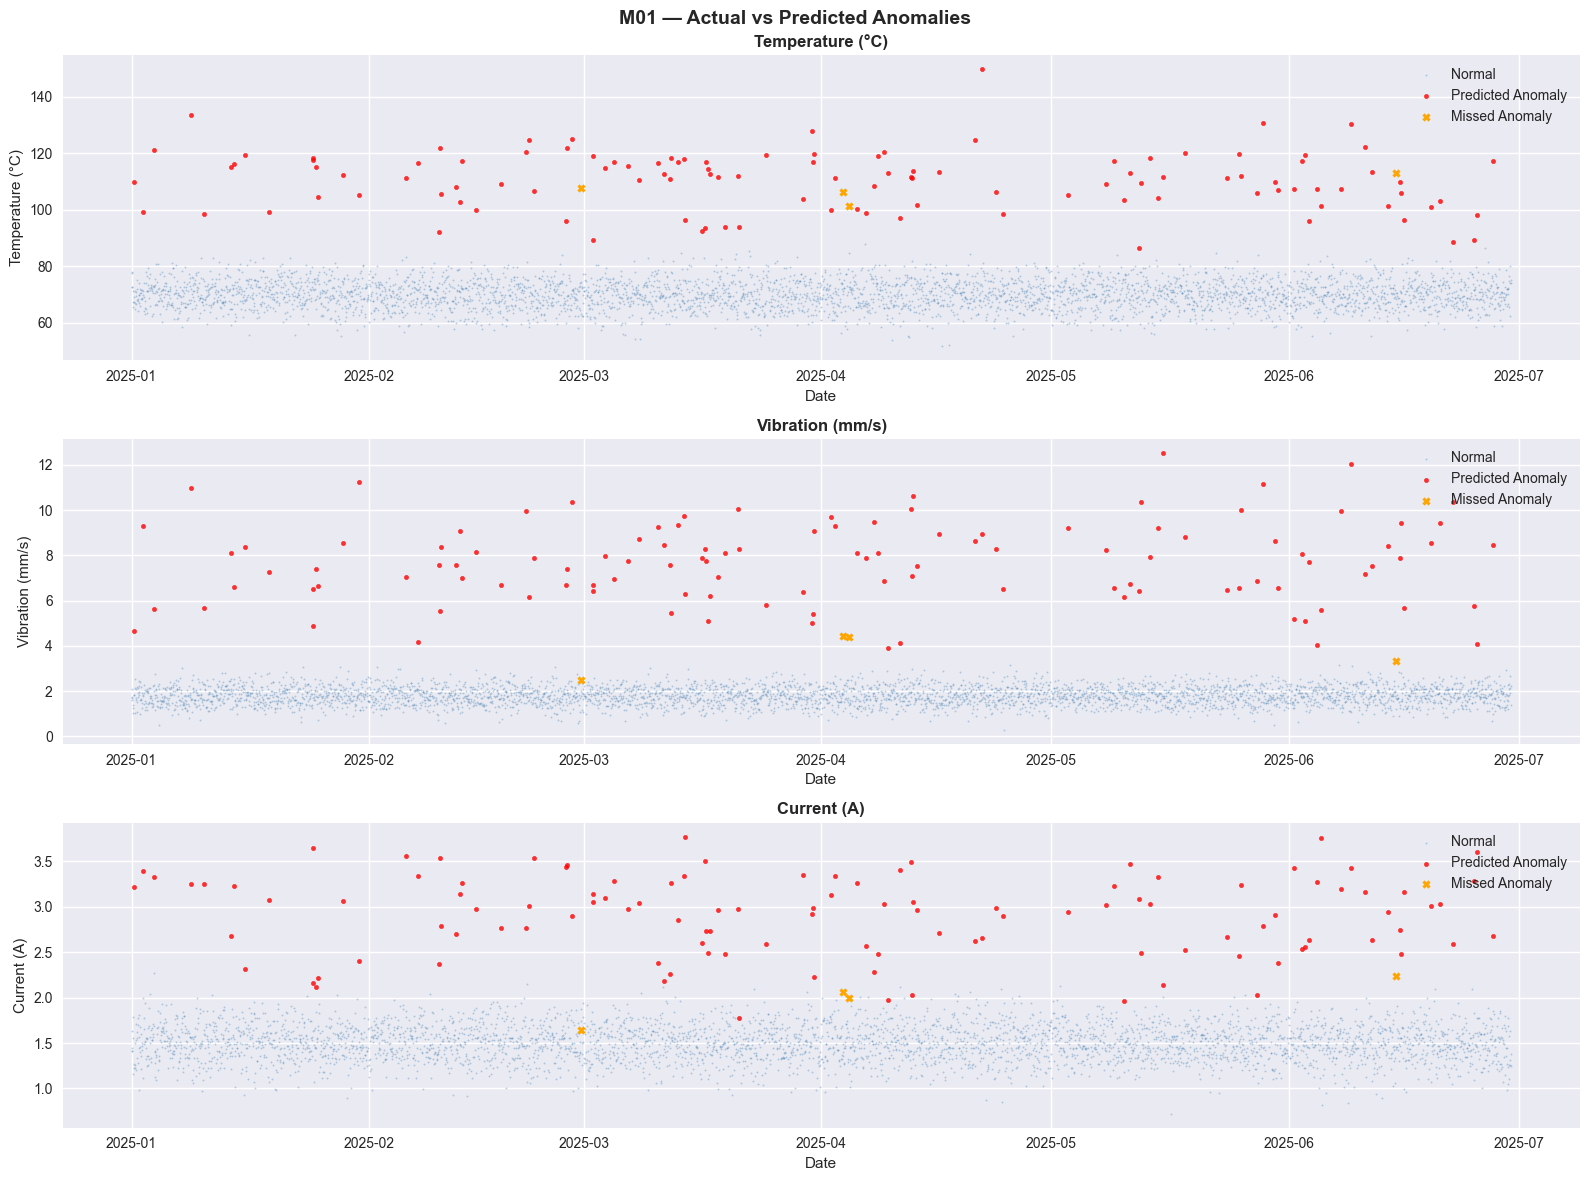

Cell 6 done!


In [14]:
# Cell 6: Visualize model predictions vs actual anomalies

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('M01 — Actual vs Predicted Anomalies', 
             fontsize=14, fontweight='bold')

m01 = df[df['machine_id'] == 'M01'].copy()

sensors = ['temperature', 'vibration', 'current']
titles = ['Temperature (°C)', 'Vibration (mm/s)', 'Current (A)']

for i, (sensor, title) in enumerate(zip(sensors, titles)):
    # Plot normal points in blue
    normal = m01[m01['predicted_anomaly'] == False]
    axes[i].scatter(normal['timestamp'], normal[sensor],
                   c='steelblue', alpha=0.3, s=1, label='Normal')
    
    # Plot predicted anomalies in red
    predicted = m01[m01['predicted_anomaly'] == True]
    axes[i].scatter(predicted['timestamp'], predicted[sensor],
                   c='red', alpha=0.8, s=10, label='Predicted Anomaly')
    
    # Plot missed anomalies in orange
    # Missed = actual anomaly BUT predicted as normal
    missed = m01[(m01['is_anomaly'] == True) & 
                 (m01['predicted_anomaly'] == False)]
    axes[i].scatter(missed['timestamp'], missed[sensor],
                   c='orange', alpha=1.0, s=30, 
                   marker='X', label='Missed Anomaly')
    
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel(title)
    axes[i].legend(loc='upper right')

plt.tight_layout()
plt.savefig('../data/predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 6 done!")

In [15]:
# Cell 7: SQL Reporting — Maintenance Priority Report

import sqlite3

# Step 1: Create in-memory database
conn = sqlite3.connect(':memory:')

# Step 2: Add severity score before loading
from scipy import stats
df['temp_zscore'] = np.abs(stats.zscore(df['temperature']))
df['vib_zscore'] = np.abs(stats.zscore(df['vibration']))
df['current_zscore'] = np.abs(stats.zscore(df['current']))

# Overall severity = average of all 3 z-scores
df['severity_score'] = (df['temp_zscore'] + 
                        df['vib_zscore'] + 
                        df['current_zscore']).round(3)

# Step 3: Load into SQL
df.to_sql('sensors', conn, index=False, if_exists='replace')
print("SQL database loaded!")

# Query 1: Anomaly count and avg severity per machine
query1 = """
SELECT 
    machine_id,
    COUNT(*) as total_readings,
    SUM(CASE WHEN predicted_anomaly = 1 THEN 1 ELSE 0 END) as anomalies_detected,
    ROUND(AVG(CASE WHEN predicted_anomaly = 1 
              THEN severity_score END), 2) as avg_severity,
    ROUND(MAX(temperature), 1) as max_temp,
    ROUND(MAX(vibration), 2) as max_vibration,
    ROUND(MAX(current), 2) as max_current
FROM sensors
GROUP BY machine_id
ORDER BY anomalies_detected DESC
"""

result1 = pd.read_sql_query(query1, conn)
print("\n=== Maintenance Priority Report ===")
print(result1)

# Query 2: Top 10 most severe anomalies across all machines
query2 = """
SELECT 
    machine_id,
    timestamp,
    ROUND(temperature, 1) as temperature,
    ROUND(vibration, 2) as vibration,
    ROUND(current, 2) as current,
    ROUND(severity_score, 2) as severity
FROM sensors
WHERE predicted_anomaly = 1
ORDER BY severity_score DESC
LIMIT 10
"""

result2 = pd.read_sql_query(query2, conn)
print("\n=== Top 10 Most Severe Anomalies ===")
print(result2)

# Query 3: Monthly anomaly trend per machine
query3 = """
SELECT 
    machine_id,
    STRFTIME('%Y-%m', timestamp) as month,
    COUNT(*) as anomalies
FROM sensors
WHERE predicted_anomaly = 1
GROUP BY machine_id, month
ORDER BY machine_id, month
"""

result3 = pd.read_sql_query(query3, conn)
print("\n=== Monthly Anomaly Trend ===")
print(result3)

SQL database loaded!

=== Maintenance Priority Report ===
  machine_id  total_readings  anomalies_detected  avg_severity  max_temp  \
0        M02            4320                 142         13.62     135.8   
1        M04            4320                 137         13.91     142.5   
2        M07            4320                 136         14.11     138.6   
3        M05            4320                 134         14.00     148.5   
4        M08            4320                 125         13.32     145.6   
5        M06            4320                 125         13.58     140.6   
6        M03            4320                 124         13.83     134.0   
7        M01            4320                 114         13.74     149.7   

   max_vibration  max_current  
0          14.21         3.93  
1          13.26         4.33  
2          12.39         4.30  
3          11.72         4.19  
4          13.69         3.76  
5          14.20         3.88  
6          12.98         4.37  
7